In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
df = pd.read_csv('/content/House_Rent_Dataset (1).csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [8]:
print('Sum of Null values:\n\n', df.isna().sum())

Sum of Null values:

 Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


In [9]:
df_clean = df.copy()
print('Sum of Null values:\n', df_clean.isna().sum())

Sum of Null values:
 Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


In [19]:
# Define target variable
y = df_clean['Rent'].astype('float32')

# Drop target and date-related/complex features from df_clean for x
# Dropping 'Posted On' and 'Floor' for simplicity in this quick fix
x = df_clean.drop(columns=['Rent', 'Posted On', 'Floor'])

# Identify categorical columns
categorical_cols = x.select_dtypes(include='object').columns

# Apply one-hot encoding
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)
x = x.astype('float32')

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state=42 )

In [21]:
x_train.shape

(3796, 2250)

In [22]:
# Assuming x has been defined and preprocessed before this cell runs
# Get the input dimension dynamically from x
input_dim = x.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(input_dim,)), # Use dynamic input_dim
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1) # No activation for regression output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Compile the model for regression
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# Summarize the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │        36,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,593 (142.94 KB)

 Trainable params: 36,593 (142.94 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 8638331904.0000 - mean_absolute_error: 35626.8281 - val_loss: 4675948544.0000 - val_mean_absolute_error: 32361.4863
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8490338304.0000 - mean_absolute_error: 34317.7188 - val_loss: 4405551104.0000 - val_mean_absolute_error: 29694.0098
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8056635392.0000 - mean_absolute_error: 29887.4785 - val_loss: 3869791744.0000 - val_mean_absolute_error: 23883.4395
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7331334144.0000 - mean_absolute_error: 24213.7227 - val_loss: 3205826560.0000 - val_mean_absolute_error: 20477.8809
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6726313984.0000 - mean_absolute_error: 24181.6992 - val_loss: 2885578240.0000 - val_mean_absolute_error: 23379.1113
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6484888064.0000 - mean_absolute_error: 26869.1191 - val_loss: 282750771

In [25]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Mean Absolute Error: {test_mae:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2823776768.0000 - mean_absolute_error: 29309.9609
Test Loss: 2823776768.0000
Test Mean Absolute Error: 29309.9609


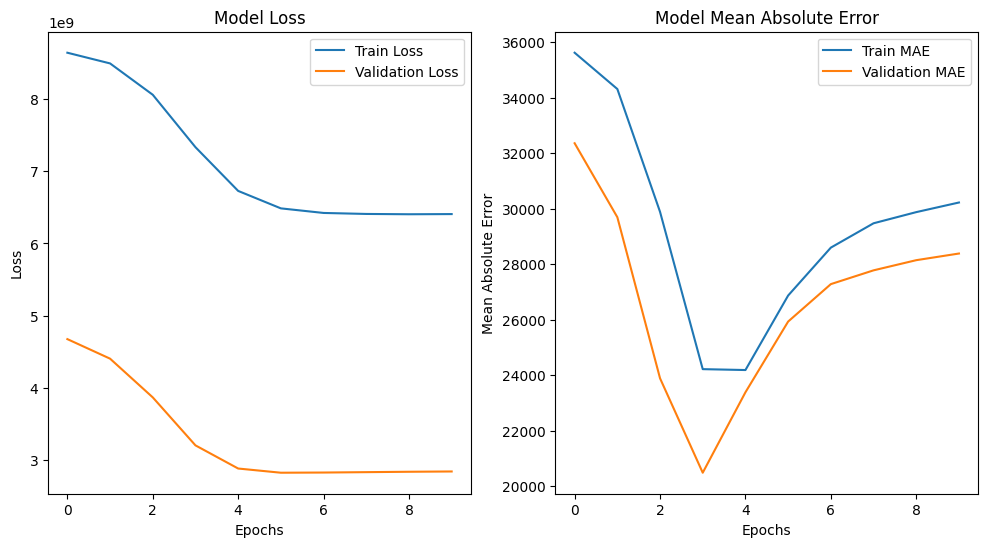

In [26]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation Mean Absolute Error
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()